In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
print("✓ Libraries imported")

✓ Libraries imported


# Module 1.2: 神经网络基础

## 1. 本章概览 (Overview)

### 📚 学习目标

1. **感知机**：理解最简单的神经网络单元
2. **多层网络**：理解如何组合神经元构建深度网络
3. **激活函数**：理解非线性的重要性
4. **前向传播**：实现完整的前向传播过程

### 🎯 核心问题

- 神经网络如何学习？
- 为什么需要多层？
- 激活函数的作用是什么？

### ⏱️ 预计学习时间：2-3小时

## 2. 动机与背景 (Motivation)

### 从生物神经元到人工神经元

生物神经元接收多个输入信号，处理后输出信号。人工神经元（感知机）模拟这个过程。

> **回顾 Module 1.1**：本章将大量使用线性代数（矩阵乘法 $Wx+b$、向量运算）和微积分（激活函数的导数）。如果对矩阵运算或求导感到生疏，建议先回顾 **Module 1.1: 数学基础回顾** 中的线性代数与微积分部分。

## 3. 理论基础 (Theory)

### 3.1 感知机 (Perceptron)

**数学模型**：

$$y = f\left(\sum_{i=1}^n w_i x_i + b\right)$$

其中：
- $x_i$: 输入特征
- $w_i$: 权重
- $b$: 偏置
- $f$: 激活函数（阶跃函数）

**几何意义**：感知机在特征空间中画一条直线（或超平面）分隔数据。

In [11]:
# 🔬 Micro Practice: Implement Perceptron
# Goal: Build a simple perceptron from scratch
# Expected outcome: Binary classification on linearly separable data

class Perceptron:
    """
    Simple perceptron for binary classification
    """

    def __init__(self, n_features):
        """
        Initialize perceptron

        Args:
            n_features: Number of input features
        """
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def predict(self, X):
        """
        Make predictions

        Args:
            X: Input features (n_samples, n_features)

        Returns:
            Predictions (0 or 1)
        """
        linear_output = X @ self.weights + self.bias
        return (linear_output >= 0).astype(int)

    def train(self, X, y, learning_rate=0.1, epochs=100):
        """
        Train perceptron using perceptron learning rule

        Args:
            X: Training features
            y: Training labels (0 or 1)
            learning_rate: Learning rate
            epochs: Number of training epochs
        """
        for epoch in range(epochs):
            for xi, yi in zip(X, y):
                prediction = self.predict(xi.reshape(1, -1))[0]
                error = yi - prediction
                self.weights += learning_rate * error * xi
                self.bias += learning_rate * error

# Test on simple dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])  # AND gate

perceptron = Perceptron(n_features=2)
perceptron.train(X, y, epochs=10)

print("Perceptron weights:", perceptron.weights)
print("Perceptron bias:", perceptron.bias)
print("\nPredictions:")
for xi, yi in zip(X, y):
    pred = perceptron.predict(xi.reshape(1, -1))[0]
    print(f"Input: {xi}, True: {yi}, Pred: {pred}")

Perceptron weights: [0.28671814 0.10196861]
Perceptron bias: -0.30000000000000004

Predictions:
Input: [0 0], True: 0, Pred: 0
Input: [0 1], True: 0, Pred: 0
Input: [1 0], True: 0, Pred: 0
Input: [1 1], True: 1, Pred: 1


/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_7635/112593583.py:30: RuntimeWarning: divide by zero encountered in matmul
  linear_output = X @ self.weights + self.bias
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_7635/112593583.py:30: RuntimeWarning: overflow encountered in matmul
  linear_output = X @ self.weights + self.bias
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_7635/112593583.py:30: RuntimeWarning: invalid value encountered in matmul
  linear_output = X @ self.weights + self.bias


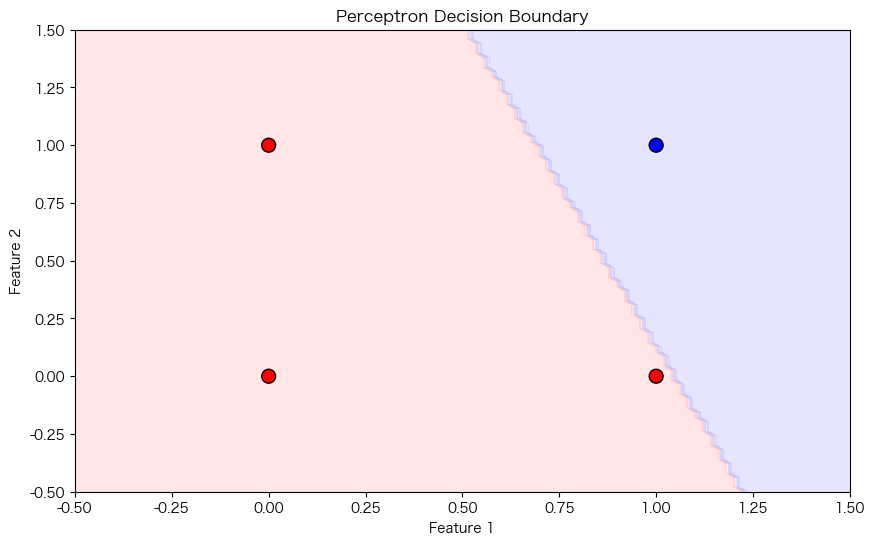

✓ 感知机成功学习了AND逻辑门！


In [12]:
# 🔬 Micro Practice: Visualize Decision Boundary
# Goal: See how perceptron separates data

def plot_decision_boundary(model, X, y):
    """Plot decision boundary of perceptron"""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(['red', 'blue']),
                edgecolors='black', s=100)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Perceptron Decision Boundary')
    plt.show()

plot_decision_boundary(perceptron, X, y)
print("✓ 感知机成功学习了AND逻辑门！")

### 3.2 激活函数 (Activation Functions)

**为什么需要激活函数？**

如果没有激活函数，多层神经网络等价于单层：
$$f(f(x)) = W_2(W_1x) = (W_2W_1)x = Wx$$

激活函数引入**非线性**，使网络能够学习复杂模式。

**常用激活函数**：

1. **Sigmoid**: $\sigma(x) = \frac{1}{1 + e^{-x}}$
   - 输出范围：(0, 1)
   - 用途：二分类输出层

2. **Tanh**: $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
   - 输出范围：(-1, 1)
   - 比Sigmoid更好（零中心）

3. **ReLU**: $\text{ReLU}(x) = \max(0, x)$
   - 最常用
   - 计算简单，缓解梯度消失

4. **Leaky ReLU**: $\text{LeakyReLU}(x) = \max(0.01x, x)$
   - 解决ReLU的"死亡"问题

5. **Softmax (归一化指数函数)**：$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$
   - 将任意实数向量转换为概率分布（所有输出之和为 1）
   - 用途：多分类问题的输出层

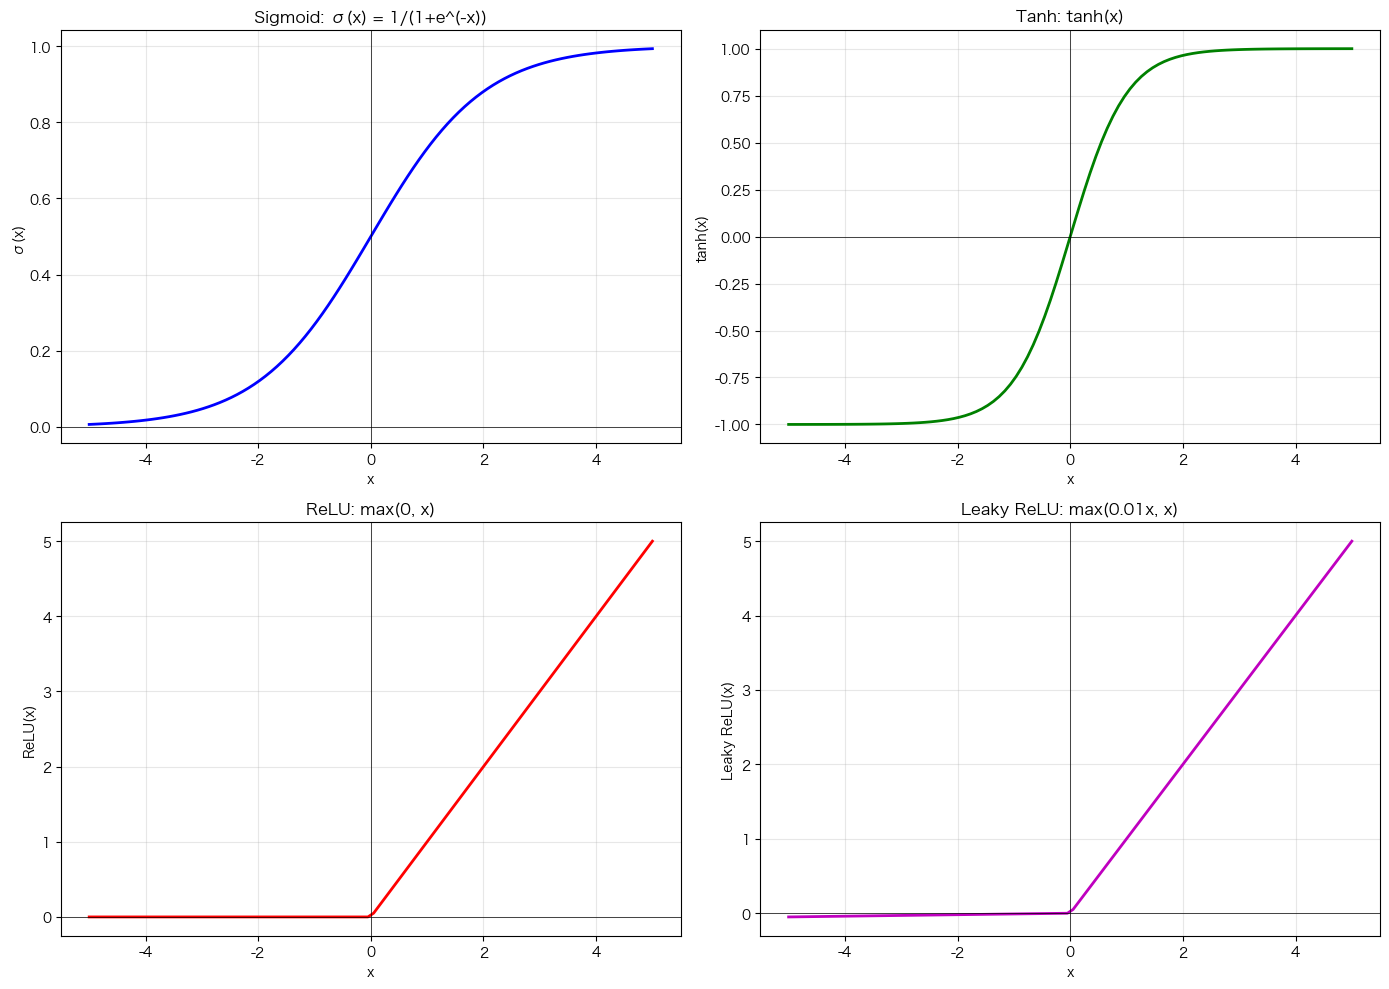

✓ 激活函数对比完成


In [13]:
# 🔬 Micro Practice: Activation Functions
# Goal: Understand different activation functions
# Expected outcome: Visualize and compare activations

def sigmoid(x):
    """Sigmoid activation"""
    return 1 / (1 + np.exp(-x))

def tanh(x):
    """Tanh activation"""
    return np.tanh(x)

def relu(x):
    """ReLU activation"""
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    """Leaky ReLU activation"""
    return np.where(x > 0, x, alpha * x)

# Visualize
x = np.linspace(-5, 5, 100)

plt.figure(figsize=(14, 10))

# Sigmoid
plt.subplot(2, 2, 1)
plt.plot(x, sigmoid(x), 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Sigmoid: σ(x) = 1/(1+e^(-x))')
plt.xlabel('x')
plt.ylabel('σ(x)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

# Tanh
plt.subplot(2, 2, 2)
plt.plot(x, tanh(x), 'g-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Tanh: tanh(x)')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

# ReLU
plt.subplot(2, 2, 3)
plt.plot(x, relu(x), 'r-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('ReLU: max(0, x)')
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

# Leaky ReLU
plt.subplot(2, 2, 4)
plt.plot(x, leaky_relu(x), 'm-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.title('Leaky ReLU: max(0.01x, x)')
plt.xlabel('x')
plt.ylabel('Leaky ReLU(x)')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("✓ 激活函数对比完成")

### 3.3 多层神经网络 (Multi-Layer Neural Network)

**架构**：

```
Input Layer → Hidden Layer(s) → Output Layer
```

**前向传播**：

$$\mathbf{h} = f(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1)$$
$$\mathbf{y} = g(\mathbf{W}_2\mathbf{h} + \mathbf{b}_2)$$

其中 $f$ 和 $g$ 是激活函数。

**为什么需要多层？**

- 单层只能学习线性可分的模式
- 多层可以学习复杂的非线性模式
- 深度网络可以学习层次化的特征表示

#### XOR 问题：单层网络的经典反例

**XOR（异或）** 是一种基本逻辑运算：两个输入**不同**时输出 1，**相同**时输出 0。

| 输入 A | 输入 B | XOR 输出 |
|--------|--------|----------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

将这 4 个点画在二维平面上，标签为 0 的点（左下、右上）和标签为 1 的点（左上、右下）呈**对角分布**——你无法用一条直线将它们分开。

```
  B
  1 | ●(1)    ○(0)
    |
  0 | ○(0)    ●(1)
    +——————————
      0        1   A
```

这就是**线性不可分**问题。感知机（单层网络）只能画一条直线做决策边界，因此无法解决 XOR。而多层网络通过引入隐藏层和非线性激活函数，可以学习更复杂的决策边界，从而解决 XOR。

> 下面的代码实践中，我们将构建一个 2 层网络来处理 XOR 问题，亲眼验证多层网络的必要性。

/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_7635/1872403283.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


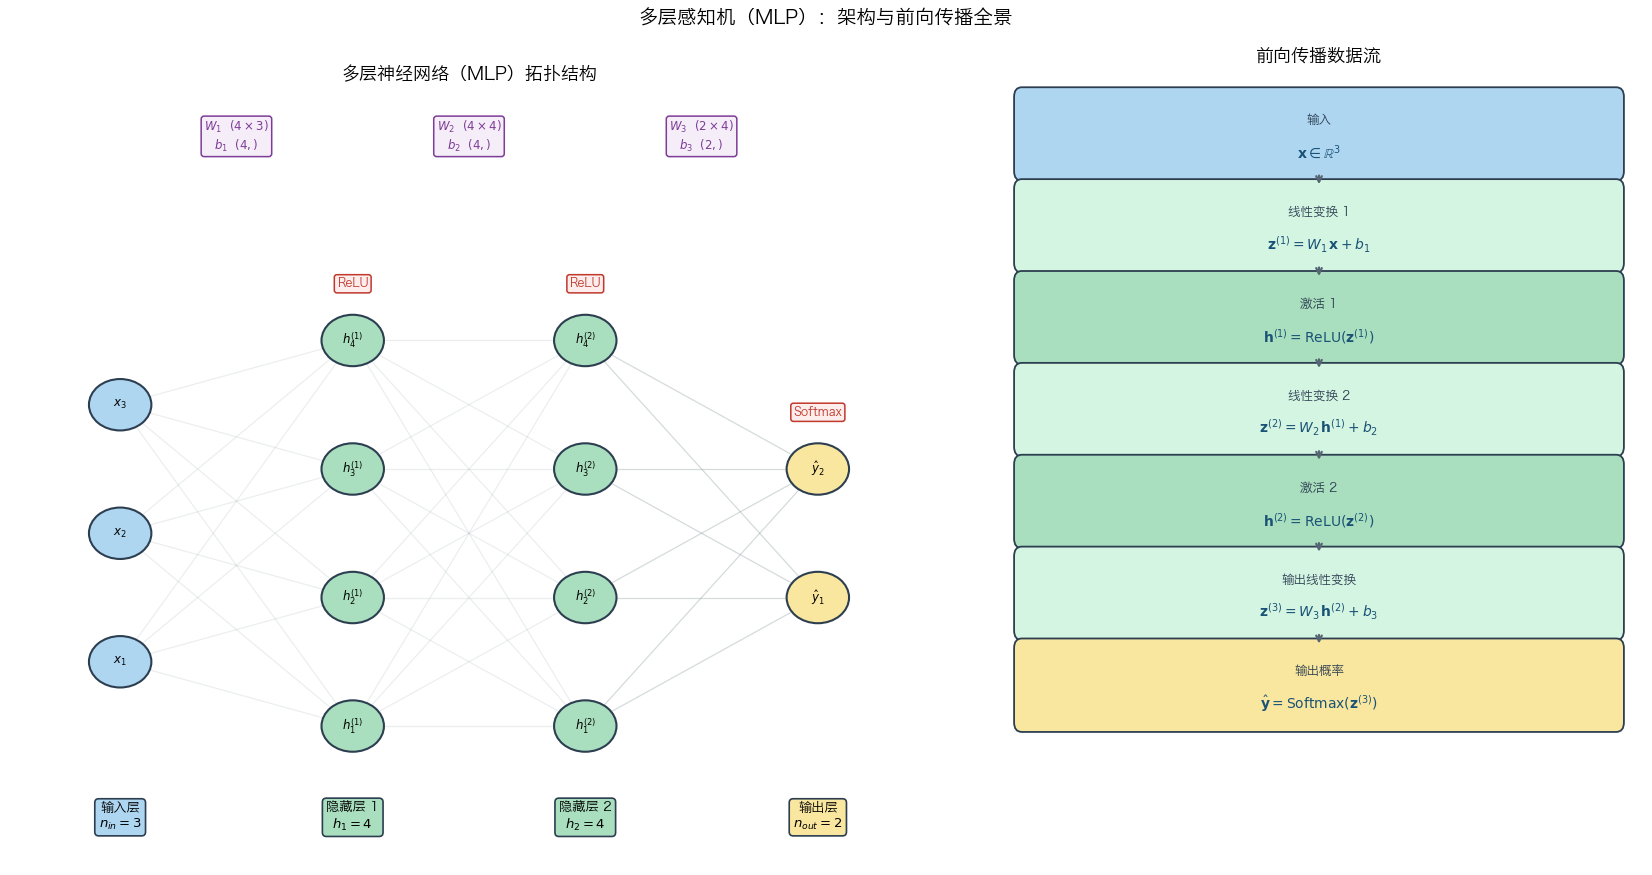

图示说明：
  左图 ── 网络拓扑：蓝色=输入层  绿色=隐藏层  黄色=输出层
          紫色框=权重矩阵维度    红色框=激活函数类型
  右图 ── 前向传播逐步变换：线性变换 → 非线性激活 → ... → 输出概率


In [14]:
# 🔬 多层神经网络架构示意图
# 左图：网络拓扑结构（神经元节点、全连接权重、权重矩阵维度、激活函数标注）
# 右图：前向传播逐步数据流（输入 → 线性变换 → 激活 → ... → 输出概率）

import matplotlib
# 优先使用支持中文的系统字体（macOS / Linux 通用）
matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Hiragino Sans GB',
                                           'STHeiti', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

def draw_mlp_architecture():
    fig = plt.figure(figsize=(17, 9))

    # ── 左图：网络拓扑 ──────────────────────────────────────────
    ax1 = fig.add_axes([0.02, 0.08, 0.54, 0.84])

    layer_sizes  = [3, 4, 4, 2]
    layer_labels = ['输入层\n$n_{in}=3$', '隐藏层 1\n$h_1=4$',
                    '隐藏层 2\n$h_2=4$', '输出层\n$n_{out}=2$']
    layer_colors = ['#AED6F1', '#A9DFBF', '#A9DFBF', '#F9E79F']

    n_layers  = len(layer_sizes)
    max_nodes = max(layer_sizes)
    x_pos     = np.linspace(0.12, 0.88, n_layers)
    node_r    = 0.034
    v_spacing = 0.68 / max_nodes

    # 每层节点纵坐标（垂直居中对齐）
    y_coords = []
    for size in layer_sizes:
        offset = (max_nodes - size) * v_spacing / 2
        y_coords.append([0.16 + offset + i * v_spacing for i in range(size)])

    # 连接线
    for l in range(n_layers - 1):
        alpha = 0.18 if layer_sizes[l] * layer_sizes[l+1] > 8 else 0.40
        for yf in y_coords[l]:
            for yt in y_coords[l+1]:
                ax1.plot([x_pos[l], x_pos[l+1]], [yf, yt],
                         color='#95A5A6', linewidth=0.9, alpha=alpha, zorder=1)

    # 节点与节点内标签
    node_labels = [
        [f'$x_{j+1}$'              for j in range(layer_sizes[0])],
        [f'$h^{{(1)}}_{j+1}$'      for j in range(layer_sizes[1])],
        [f'$h^{{(2)}}_{j+1}$'      for j in range(layer_sizes[2])],
        [f'$\\hat{{y}}_{j+1}$'     for j in range(layer_sizes[3])],
    ]
    for l in range(n_layers):
        for j, y in enumerate(y_coords[l]):
            ax1.add_patch(plt.Circle((x_pos[l], y), node_r,
                                     color=layer_colors[l], ec='#2C3E50',
                                     linewidth=1.5, zorder=3))
            ax1.text(x_pos[l], y, node_labels[l][j],
                     ha='center', va='center', fontsize=8.5,
                     fontweight='bold', zorder=4)

    # 层标签（底部）
    for l in range(n_layers):
        ax1.text(x_pos[l], 0.04, layer_labels[l],
                 ha='center', va='center', fontsize=9.5, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor=layer_colors[l],
                           edgecolor='#2C3E50', linewidth=1.2))

    # 权重矩阵维度标注（层间连线中点上方，紫色）
    for l, label in enumerate([
        '$W_1$  $(4\\times3)$\n$b_1$  $(4,)$',
        '$W_2$  $(4\\times4)$\n$b_2$  $(4,)$',
        '$W_3$  $(2\\times4)$\n$b_3$  $(2,)$',
    ]):
        ax1.text((x_pos[l] + x_pos[l+1]) / 2, 0.94, label,
                 ha='center', va='center', fontsize=8.5, color='#7D3C98',
                 bbox=dict(boxstyle='round,pad=0.25', facecolor='#F5EEF8',
                           edgecolor='#7D3C98', linewidth=1.1))

    # 激活函数标注（各隐藏/输出层顶部，红色）
    for l, act in enumerate(['ReLU', 'ReLU', 'Softmax'], start=1):
        ax1.text(x_pos[l], max(y_coords[l]) + 0.075, act,
                 ha='center', va='center', fontsize=8.5, color='#C0392B',
                 bbox=dict(boxstyle='round,pad=0.22', facecolor='#FDEDEC',
                           edgecolor='#C0392B', linewidth=1.1))

    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1); ax1.axis('off')
    ax1.set_title('多层神经网络（MLP）拓扑结构', fontsize=13, fontweight='bold', pad=8)

    # ── 右图：前向传播数据流 ────────────────────────────────────
    ax2 = fig.add_axes([0.60, 0.06, 0.38, 0.88])
    ax2.axis('off')

    steps = [
        ('输入',         r'$\mathbf{x} \in \mathbb{R}^{3}$',                      '#AED6F1'),
        ('线性变换 1',   r'$\mathbf{z}^{(1)} = W_1\,\mathbf{x} + b_1$',           '#D5F5E3'),
        ('激活 1',       r'$\mathbf{h}^{(1)} = \mathrm{ReLU}(\mathbf{z}^{(1)})$', '#A9DFBF'),
        ('线性变换 2',   r'$\mathbf{z}^{(2)} = W_2\,\mathbf{h}^{(1)} + b_2$',     '#D5F5E3'),
        ('激活 2',       r'$\mathbf{h}^{(2)} = \mathrm{ReLU}(\mathbf{z}^{(2)})$', '#A9DFBF'),
        ('输出线性变换', r'$\mathbf{z}^{(3)} = W_3\,\mathbf{h}^{(2)} + b_3$',     '#D5F5E3'),
        ('输出概率',     r'$\hat{\mathbf{y}} = \mathrm{Softmax}(\mathbf{z}^{(3)})$', '#F9E79F'),
    ]

    box_h, gap, y_top = 0.094, 0.022, 0.97
    for i, (title, formula, color) in enumerate(steps):
        y0 = y_top - i * (box_h + gap) - box_h
        ax2.add_patch(plt.matplotlib.patches.FancyBboxPatch(
            (0.04, y0), 0.92, box_h, boxstyle='round,pad=0.012',
            facecolor=color, edgecolor='#2C3E50', linewidth=1.3, zorder=2))
        ax2.text(0.50, y0 + box_h * 0.68, title,
                 ha='center', va='center', fontsize=9,
                 fontweight='bold', color='#2C3E50', zorder=3)
        ax2.text(0.50, y0 + box_h * 0.25, formula,
                 ha='center', va='center', fontsize=10, color='#1A5276', zorder=3)
        if i < len(steps) - 1:
            ay = y0 - 0.002
            ax2.annotate('', xy=(0.50, ay - gap + 0.004), xytext=(0.50, ay),
                         arrowprops=dict(arrowstyle='->', color='#566573', lw=1.6),
                         zorder=4)

    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
    ax2.set_title('前向传播数据流', fontsize=13, fontweight='bold', pad=8)

    plt.suptitle('多层感知机（MLP）：架构与前向传播全景',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print("图示说明：")
    print("  左图 ── 网络拓扑：蓝色=输入层  绿色=隐藏层  黄色=输出层")
    print("          紫色框=权重矩阵维度    红色框=激活函数类型")
    print("  右图 ── 前向传播逐步变换：线性变换 → 非线性激活 → ... → 输出概率")

draw_mlp_architecture()

In [15]:
# 🔬 Micro Practice: Multi-Layer Neural Network
# Goal: Build a 2-layer neural network from scratch
# Expected outcome: Solve XOR problem (not linearly separable)

class NeuralNetwork:
    """
    Simple 2-layer neural network
    """

    def __init__(self, input_size, hidden_size, output_size):
        """
        Initialize network

        Args:
            input_size: Number of input features
            hidden_size: Number of hidden units
            output_size: Number of output units
        """
        # Initialize weights with small random values
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros(output_size)

    def forward(self, X):
        """
        Forward propagation

        Args:
            X: Input features (n_samples, input_size)

        Returns:
            output: Network output
            cache: Intermediate values for backprop
        """
        # Hidden layer
        z1 = X @ self.W1 + self.b1
        a1 = sigmoid(z1)  # Activation

        # Output layer
        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)  # Activation

        cache = {'X': X, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2}
        return a2, cache

    def predict(self, X):
        """Make predictions"""
        output, _ = self.forward(X)
        return (output > 0.5).astype(int)

# Test on XOR problem (not linearly separable!)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])  # XOR gate

nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1)

print("XOR Problem (before training):")
output, _ = nn.forward(X_xor)
print("Predictions:", output.flatten())
print("True labels:", y_xor.flatten())
print("\n注意：训练前的预测是随机的")
print("下一章我们将学习如何训练这个网络（反向传播）")

XOR Problem (before training):
Predictions: [0.40851564 0.4118875  0.40892684 0.4120896 ]
True labels: [0 1 1 0]

注意：训练前的预测是随机的
下一章我们将学习如何训练这个网络（反向传播）


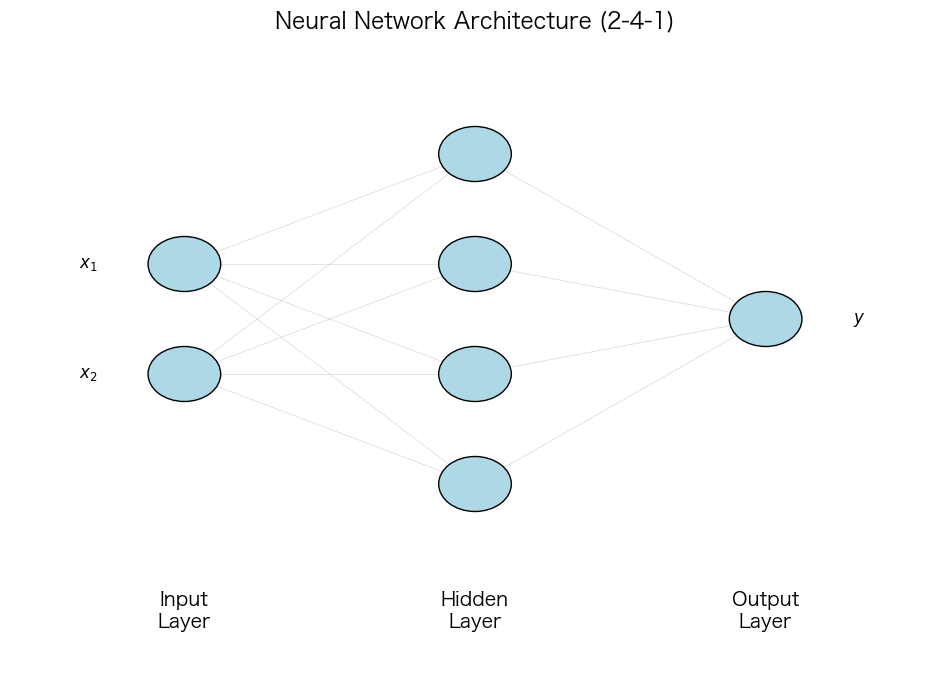

✓ 网络结构：2个输入 → 4个隐藏神经元 → 1个输出


In [16]:
# 🔬 Micro Practice: Visualize Network Architecture
# Goal: Understand network structure

def visualize_network():
    """Visualize neural network architecture"""
    fig, ax = plt.subplots(figsize=(12, 8))

    # Layer positions
    layer_sizes = [2, 4, 1]
    layer_names = ['Input\nLayer', 'Hidden\nLayer', 'Output\nLayer']
    v_spacing = 1.0 / max(layer_sizes)
    h_spacing = 1.0 / (len(layer_sizes) - 1)

    # Draw nodes
    for i, (size, name) in enumerate(zip(layer_sizes, layer_names)):
        layer_top = v_spacing * (size - 1) / 2.0 + 0.5
        for j in range(size):
            circle = plt.Circle((i * h_spacing, layer_top - j * v_spacing),
                               v_spacing/4.0, color='lightblue', ec='black', zorder=4)
            ax.add_artist(circle)

            # Add labels
            if i == 0:
                ax.text(i * h_spacing - 0.15, layer_top - j * v_spacing,
                       f'$x_{j+1}$', fontsize=12, ha='right', va='center')
            elif i == len(layer_sizes) - 1:
                ax.text(i * h_spacing + 0.15, layer_top - j * v_spacing,
                       f'$y$', fontsize=12, ha='left', va='center')

        # Layer names
        ax.text(i * h_spacing, -0.2, name, fontsize=14, ha='center', weight='bold')

    # Draw connections
    for i in range(len(layer_sizes) - 1):
        layer_top_from = v_spacing * (layer_sizes[i] - 1) / 2.0 + 0.5
        layer_top_to = v_spacing * (layer_sizes[i+1] - 1) / 2.0 + 0.5
        for j in range(layer_sizes[i]):
            for k in range(layer_sizes[i+1]):
                ax.plot([i * h_spacing, (i+1) * h_spacing],
                       [layer_top_from - j * v_spacing, layer_top_to - k * v_spacing],
                       'gray', alpha=0.3, linewidth=0.5)

    ax.axis('off')
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.3, 1.1)
    plt.title('Neural Network Architecture (2-4-1)', fontsize=16, weight='bold', pad=20)
    plt.show()

visualize_network()
print("✓ 网络结构：2个输入 → 4个隐藏神经元 → 1个输出")

## 4-6. 实践总结

本章我们实现了：
- ✅ 感知机（单层神经网络）
- ✅ 激活函数（引入非线性）
- ✅ 多层神经网络（前向传播）

**下一章预告**：我们将学习如何训练这些网络（反向传播算法）。

## 7. 常见问题与调试

### Q1: 为什么感知机不能解决XOR问题？

**A:** XOR不是线性可分的。感知机只能画一条直线分隔数据，而XOR需要两条线。

### Q2: 隐藏层应该有多少个神经元？

**A:** 没有固定规则，通常：
- 从小开始（如输入维度的2倍）
- 根据任务复杂度调整
- 过多会过拟合，过少会欠拟合

### Q3: 应该选择哪个激活函数？

**A:**
- 隐藏层：ReLU（默认选择）
- 输出层：根据任务
  - 二分类：Sigmoid
  - 多分类：Softmax
  - 回归：线性（无激活）

## 8. 总结与展望

### 核心要点

1. **感知机**：最简单的神经网络，但只能处理线性可分问题
2. **激活函数**：引入非线性，使网络能学习复杂模式
3. **多层网络**：组合多个层，学习层次化特征

### 与其他技术的联系

```
感知机 → 多层网络 → 深度网络
   ↓         ↓          ↓
线性分类  非线性分类  复杂模式识别
```

### 下一章预告

**Module 1.3: 反向传播**
- 如何计算梯度？
- 如何更新权重？
- 完整的训练流程

### 💡 思考题

1. 为什么需要偏置项 $b$？
2. 如果所有激活函数都是线性的会怎样？
3. 更深的网络一定更好吗？
4. 如何初始化权重？

## 9. 思考题参考答案

### 问题 1：为什么需要偏置项 $b$？

偏置项的作用是**平移激活函数**，使神经元能够在输入为零时仍然输出非零值。

**直觉理解**：以单个神经元为例，若无偏置：

$$y = f(wx)$$

决策边界必须过原点，极大限制了模型的表达能力。加入偏置后：

$$y = f(wx + b)$$

决策边界可以平移到任意位置，模型灵活性大幅提升。

**类比**：线性函数 $y = kx$（过原点）vs $y = kx + b$（可平移）。偏置相当于给网络增加了一个可学习的"基准值"，让每个神经元都能独立地调整激活阈值。

---

### 问题 2：如果所有激活函数都是线性的会怎样？

**结论：无论网络有多少层，都等价于一个单层线性模型。**

设两层网络，激活函数均为线性（$f(x) = x$）：

$$h = W_1 x + b_1$$
$$y = W_2 h + b_2 = W_2(W_1 x + b_1) + b_2 = (W_2 W_1)x + (W_2 b_1 + b_2) = W' x + b'$$

$N$ 层全线性网络同理，最终仍等价于 $y = W'x + b'$。

> **联系 Module 1.1**：这里用到了矩阵乘法的结合律 $(W_2 W_1)x = W_2(W_1 x)$。如果觉得矩阵运算不够直观，可回顾 M1.1 中线性代数的矩阵乘法部分。

**后果**：
- 网络失去表达非线性函数的能力
- 无法解决 XOR、圆形分类等非线性可分问题
- 增加网络深度毫无意义，完全浪费计算资源
- 这正是激活函数不可或缺的根本原因

---

### 问题 3：更深的网络一定更好吗？

**不一定。** 深度是把双刃剑：

**更深网络的优势**：
- 能学习更抽象的层次化特征（低层学边缘，高层学语义）
- 理论上拥有更强的表达能力
- 在图像、语音、NLP 等复杂任务上效果显著更好

**更深网络的问题**：

| 问题 | 原因 | 解决方案 |
|------|------|----------|
| 梯度消失/爆炸 | 梯度在反向传播时逐层缩小或放大 | BatchNorm、残差连接、梯度裁剪 |
| 过拟合 | 参数量过多，记住了训练数据 | Dropout、正则化、数据增强 |
| 训练困难 | 优化景观复杂，难以收敛 | 更好的初始化、自适应优化器 |
| 计算代价高 | 参数量和计算量剧增 | 剪枝、量化、知识蒸馏 |

**实践原则**：从简单模型开始，根据任务复杂度和数据量逐步增加深度，而不是盲目堆叠层数。

---

### 问题 4：如何初始化权重？

权重初始化对训练稳定性至关重要，核心目标是**保持各层激活值和梯度的方差稳定**。

> **联系 Module 1.1**：初始化策略的推导依赖概率论中的方差传播公式（$\text{Var}(aX) = a^2 \text{Var}(X)$）。这正是 M1.1 思考题 Q3 讨论的"概率工具如何帮助设计网络"的具体体现。

**不能全零初始化**：
- 所有神经元输出相同，梯度相同，参数更新完全对称
- 神经元永远学不到不同的特征（对称性破坏问题）

**常用初始化策略**：

**Xavier 初始化**（适用于 Sigmoid/Tanh）：

$$W \sim \mathcal{N}\left(0, \frac{2}{n_{in} + n_{out}}\right)$$

推导思路：使前向传播和反向传播中激活值的方差保持一致。

**He 初始化**（适用于 ReLU）：

$$W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right)$$

由于 ReLU 将一半神经元置零，方差系数调整为 $2/n_{in}$ 以补偿这一损失。

**偏置初始化**：通常初始化为 0，不影响对称性破坏，也不会引入初始偏差。

**经验总结**：PyTorch/TensorFlow 等框架默认使用 Kaiming（He）初始化，实践中直接使用框架默认值即可，仅在特殊网络结构下需要手动调整。